In [1]:
import time
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import requests
from tqdm.notebook import tqdm
from neo4j import GraphDatabase

from dotenv import load_dotenv
import os

In [2]:
N_SAMPLE   = 2000
GRID_STEP  = 0.01
K_NEAREST  = 5
SLEEP_SEC  = 0.05
PERCENTILE_LOW  = 20
GEOJSON    = "lombardia.geojson"

OSRM_BASE = "https://router.project-osrm.org"

load_dotenv()

NEO4J_URI      = os.getenv("NEO4J_URI")
NEO4J_USER     = os.getenv("NEO4J_USER")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)
driver.verify_connectivity()
print(f"Connesso a {NEO4J_URI}")

def run(cypher, **params):
    with driver.session(database=NEO4J_DATABASE) as s:
        return pd.DataFrame([r.data() for r in s.run(cypher, **params)])

Connesso a neo4j+s://78976b17.databases.neo4j.io


In [3]:
regione = gpd.read_file(GEOJSON)

points = regione.dissolve().sample_points(N_SAMPLE)

sample = [{"lat": p.y, "lon": p.x} for p in points.iloc[0].geoms]

In [4]:
hospitals_df = run("""
    MATCH (o:Hub)-[:HA_AREA]->(a:AreaSpecialistica) 
    WHERE o.Coordinate IS NOT NULL AND a.Nome = "PRONTO SOCCORSO"
    RETURN
        o.Nome AS Nome,
        o.Coordinate.latitude  AS lat,
        o.Coordinate.longitude AS lon
""")

hosp_lats = hospitals_df["lat"].to_numpy()
hosp_lons = hospitals_df["lon"].to_numpy()

hospitals_df.head(20)

,Nome,lat,lon
0,OSPEDALE POLICLINICO SAN MATTEO DI PAVIA,45.196134,9.148955
1,PRESIDIO OSPEDALIERO ALESSANDRO MANZONI DI LECCO,45.852347,9.413367
2,OSPEDALE DI CIRCOLO E FONDAZIONE MACCHI DI VARESE,45.807808,8.837523
3,OSPEDALE PAPA GIOVANNI XXIII DI BERGAMO,45.686830,9.639308
4,OSPEDALE NIGUARDA DI MILANO,45.510661,9.188026
5,HUMANITAS RESEARCH HOSPITAL DI ROZZANO,45.372482,9.167666
6,FONDAZIONE IRCCS SAN GERARDO DEI TINTORI DI MO...,45.602275,9.260494
7,CENTRO CARDIOLOGICO MONZINO DI MILANO,45.444122,9.262518
8,FONDAZIONE IRCCS CA' GRANDA OSPEDALE MAGGIORE ...,45.458994,9.194901
9,ISTITUTO NAZIONALE DEI TUMORI,45.474386,9.232180


In [5]:
def osrm_table(origin_lat, origin_lon, candidates: pd.DataFrame):
    coord_str = f"{origin_lon},{origin_lat}"
    for _, r in candidates.iterrows():
        coord_str += f";{r['lon']},{r['lat']}"
    dest_str = ";".join(str(i + 1) for i in range(len(candidates)))
    url = (
        f"{OSRM_BASE}/table/v1/driving/{coord_str}"
        f"?sources=0&destinations={dest_str}&annotations=duration"
    )
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    if data.get("code") != "Ok":
        return [None] * len(candidates)
    return data["durations"][0]

def osrm_route(origin_lat, origin_lon, dest_lat, dest_lon):
    url = (
        f"{OSRM_BASE}/route/v1/driving/"
        f"{origin_lon},{origin_lat};{dest_lon},{dest_lat}"
        f"?overview=full&geometries=geojson"
    )
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    if data.get("code") != "Ok":
        return None
    return data["routes"][0]["geometry"]["coordinates"]

def snap(coord, decimals=5):
    return (round(coord[0], decimals), round(coord[1], decimals))

In [6]:
segment_counter = Counter()

for v in tqdm(sample, desc="Routing"):
    lat, lon = v["lat"], v["lon"]

    dist2 = (hosp_lats - lat) ** 2 + (hosp_lons - lon) ** 2
    idx_k = np.argpartition(dist2, K_NEAREST)[:K_NEAREST]
    candidates = hospitals_df.iloc[idx_k].reset_index(drop=True)

    durations = osrm_table(lat, lon, candidates)

    best_idx, best_dur = None, float("inf")
    for i, dur in enumerate(durations):
        if dur is not None and dur < best_dur:
            best_dur, best_idx = dur, i

    best = candidates.iloc[best_idx]

    route_coords = osrm_route(lat, lon, best["lat"], best["lon"])

    for a, b in zip(route_coords[:-1], route_coords[1:]):
        segment_counter[(snap(a), snap(b))] += 1

    time.sleep(SLEEP_SEC)

print(f"Segmenti unici: {len(segment_counter):,}")

Routing:   0%|          | 0/2000 [00:00<?, ?it/s]

Segmenti unici: 396,154


In [7]:
rows = [
    {"count": cnt, "geometry": LineString([(a[0], a[1]), (b[0], b[1])])}
    for (a, b), cnt in segment_counter.items()
]
gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")

gdf["pct"] = gdf["count"].rank(pct=True) * 100

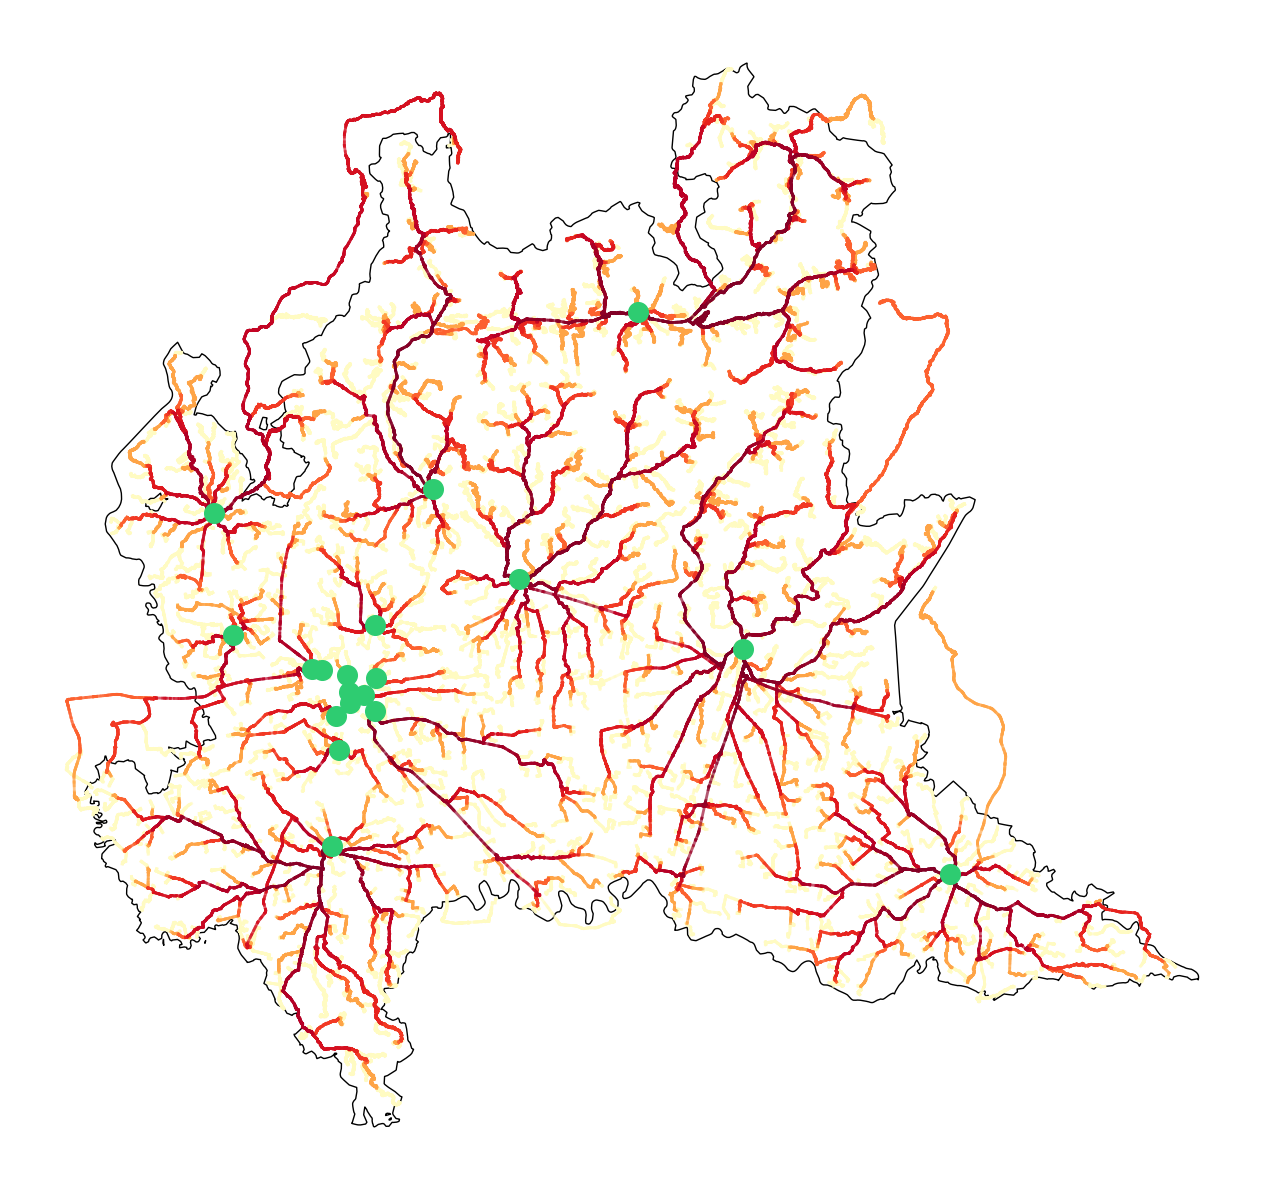

In [10]:
gdf_sorted = gdf.sort_values("pct")

cmap = plt.get_cmap("YlOrRd")

pct_min = PERCENTILE_LOW
pct_max = 100
norm = mcolors.Normalize(vmin=pct_min, vmax=pct_max)

def pct_to_hex(pct):
    rgba = cmap(norm(np.clip(pct, pct_min, pct_max)))
    return mcolors.to_hex(rgba)

fig, ax = plt.subplots(figsize=(14, 12))

regione.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

gdf_low = gdf_sorted[gdf_sorted["pct"] < PERCENTILE_LOW]
for _, row in gdf_low.iterrows():
    x, y = row.geometry.xy
    ax.plot(x, y, color="grey", linewidth=0.8, alpha=1)

gdf_high = gdf_sorted[gdf_sorted["pct"] >= PERCENTILE_LOW]
for _, row in gdf_high.iterrows():
    x, y = row.geometry.xy
    ax.plot(x, y, color=pct_to_hex(row["pct"]), linewidth=2, alpha=0.65)

ax.scatter(
    hospitals_df["lon"], hospitals_df["lat"],
    s=200, color="#2ecc71", zorder=5,
)

"""sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Percentile di utilizzo", fontsize=10)"""

ax.set_axis_off()
plt.tight_layout()
plt.savefig("RouteHub.png", dpi=300, bbox_inches="tight")
plt.show()